In [2]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version
import json


In [3]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
# if data["dn"].lower() == "dayu19a":
#     bin_range = (1676, 1727)
#     data_color = "red"
#     data_name = r"$A_1$"
#     ylim_max = 0.4
# elif data["dn"].lower() == "dayu19b":
#     true_sample = np.load(base_path / "inputdata_260219B" / "true_sample.npy")
#     bin_range = (1660, 1720)
#     data_color = "orange"
#     data_name = r"$A_2$"
#     ylim_max = 0.15
# if data["dn"].lower() == "dayu19c":
#     true_sample = np.load(base_path / "inputdata_260219C" / "true_sample.npy")
#     bin_range = (1680, 1720)
#     data_color = "yellow"
#     data_name = r"$A_3$"
#     ylim_max = 0.25
# print(true_sample)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
print(true_ages)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal
dayu_d18o
[1983.         1974.04559088 1959.31183885 1949.14923736 1940.19874042
 1925.43808904 1912.06117865 1906.2793322  1882.96682822 1877.73363719
 1868.28535596 1866.63152448 1852.02710994 1849.92490029 1833.93988239
 1823.73176077 1809.31986423 1795.9675332  1783.19696138 1779.01842624
 1750.71969027 1725.92385321 1696.47174745 1690.27067128 1680.96821773
 1673.08200744 1664.62669161 1660.44487045 1648.50035293 1616.92524865
 1610.91852632 1607.06860428 1597.87735026 1587.98476912 1577.1934799
 1571.65562156 1559.5271846  1557.5428288  1515.68068719 1511.80787429
 1506.43315654 1485.80277906 1389.26921705 1381.87694375 1340.32975062
 1305.73656076 1294.63917822 1289.4067502  1284.21112873 1270.87451933
 1263.60735313]


In [4]:
base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 10000
# adam_hash_ee = hash_configs(adam_config_ee, data)

# adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

# starting_points = np.load(adam_dir / "adam_samples.npy")
# energies = np.load(adam_dir / "adam_energies.npy")

# indices = np.argsort(energies)
# sp = starting_points[indices][:pt_config["nt"]]
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [5]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

[[ 0  1  1 ... 18  4  4]
 [ 1  0  3 ...  4 18 18]
 [ 2  3  0 ...  0  9  9]
 ...
 [17 16 16 ...  3  2  2]
 [18 18 18 ... 16  1  1]
 [19 19 19 ...  1 16 16]]
(20, 10001)
[[ 0  1  1 ... 18  4  4]
 [ 1  0  3 ...  4 18 18]
 [ 2  3  0 ...  0  9  9]
 ...
 [17 16 16 ...  3  2  2]
 [18 18 18 ... 16  1  1]
 [19 19 19 ...  1 16 16]]


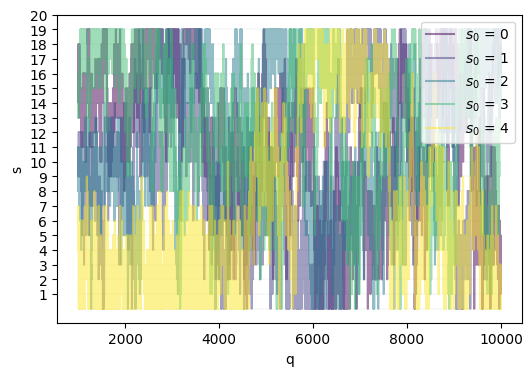

In [7]:
import matplotlib as mpl

num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy")
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
# temp_indices = (temp_indices == 19).argmax(axis=0)
print(temp_indices)
print(np.shape(temp_indices))
plt.figure(figsize=(6, 4))
xmin = 1000
xmax = 10000
# for i in range(len(temp_indices)):
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
print(temp_indices)
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [9]:
cutout = 1000
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, cutout:])
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(round_trip / (num_samples * num_temps))


0.00033329630041106545


In [10]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [11]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(pt_config["nt"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(pt_config["nt"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(pt_config["nt"])]
print(min_energies)

[np.float64(81.97312117393759), np.float64(83.54556002954074), np.float64(85.5623165291147), np.float64(86.73400243424916), np.float64(91.38617176565015), np.float64(93.68773540759058), np.float64(96.70333586909965), np.float64(100.1529298673365), np.float64(104.7773332575153), np.float64(109.90492601320466), np.float64(114.79796599377669), np.float64(121.4296818019831), np.float64(127.51470619041748), np.float64(134.61510267141492), np.float64(142.7637719775895), np.float64(155.53598908445997), np.float64(165.35067014839186), np.float64(179.03742864050366), np.float64(193.00793967553244), np.float64(216.42887569525058)]


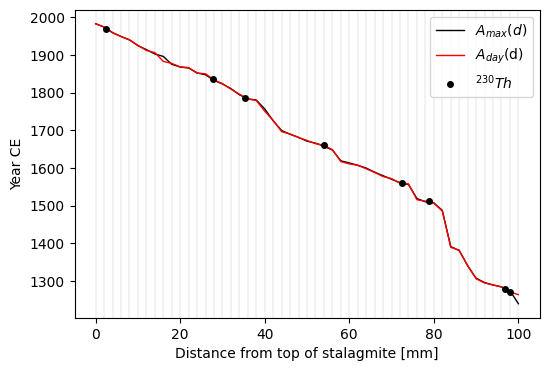

In [12]:
chain = -1
fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()

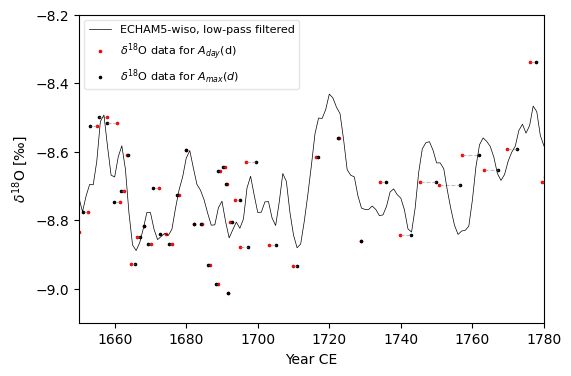

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
# 1. Define your two sets of X coordinates
x_data = data["d18ota"]
x_model = np.interp(
    data["d18od"], 
    data["cs"], 
    data["th"] - data["dc"] * np.hstack(([chain], np.cumsum(min_energy_samples[chain])))
)
y_vals = data["d18o"] # The Y values are the same for both, right?
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.scatter(
    x_data, 
    y_vals, 
    color="red", 
    marker = ".", 
    s = 10,
    label=fr"$\delta^{{{18}}}$O data for {data_name}(d)"
)

# ax.scatter(
#     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain])))), 
#     data["d18o"], 
#     # yerr=data["d18os"],       # The error values (can be a constant or array)
#     color="black", 
#     marker="*", 
#     s=10,                # Makes the stars smaller (default is 6)
#     # linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
#     label=r"Data regenerated from $A_{close}(d)$"
# )

ax.scatter(
    x_model, 
    y_vals, 
    # yerr=data["d18os"],       # The error values (can be a constant or array)
    color="black", 
    marker=".", 
    s=10,                # Makes the stars smaller (default is 6)
    # linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    # elinewidth=0.5,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)

# 2. Loop through and draw a line between each corresponding pair
for i in range(len(y_vals)):
    ax.plot(
        [x_data[i], x_model[i]], # X-start to X-end
        [y_vals[i], y_vals[i]], # Y-start to Y-end (stays on same horizontal line)
        color="grey", 
        linestyle="--", 
        linewidth=0.8,
        alpha=0.5,           # Makes lines subtle so they don't crowd the plot
        zorder=1             # Puts the lines behind the scatter stars
    )
# ax.plot(np.interp(data["d18od"], data["cs"], true_ages), data["d18o"], color = "purple", linestyle = '--', label = "true data")
# ax.scatter(np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), data["d18o"], color = "red", marker = 'o', markersidth = 0.1, label = "most likely data")
plt.xlim((1650, 1780))
plt.ylim((-9.1, -8.2))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend(loc = "upper left", framealpha=0.5, prop={'size': 8})
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [15]:
import arviz as az
# for i in range(len(samples[-1,0,:])):    
#     print(f"ess x[{i}]: {az.ess(samples[-1, :, i], method="bulk")}")

ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[4775.4031759  4828.82248025 5276.13024872 3167.58846165 1608.52465932
 2097.24625755 3276.14512402 1878.44120102 1743.76600717 2921.09658718
 2822.46645761 1796.03709166 2050.60988305 4165.53917332 5127.57166816
 5041.04477109 3289.60229329  676.57707185  147.51325436  289.73280607
  276.24517601  302.5393039   963.75787534  684.80684715 1705.44626656
 1655.89334928 2471.2547521  3040.05962364 3762.38700163 2410.7282352
 2896.59779126 4092.6366024  4112.73852784 4421.94011654 4272.19879828
 2926.06079771 3079.76900539 3633.56340784 4709.42719619 3219.42585635
 3092.02278772 3474.320138   6243.58672051 6005.90332394 6523.98071154
 7476.26466413 5090.35925488 4592.55463832 4826.63342596  547.9747645 ]
147.5132543617829


In [16]:
print(output_dir)
print(min_ess)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal\output\dayu_d18o\0\70ab9a1e78
147.5132543617829


In [17]:
# short_samples = samples[:, 500::10, :]
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[0,:,0])
# # for i in range(pt_config["nt"]):
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[-1, j, :],
#         color=colors[0],
#         alpha=0.3,
#         linewidth=0.1,
#     )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_samples.jpg")
# plt.show()

In [18]:
# short_samples = samples[:, 500::10, :]
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[-1,:,0])
# # for i in range(pt_config["nt"]):
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[0, j, :],
#         color=colors[0],
#         alpha=0.3,
#         linewidth=0.1,
#     )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_highT_samples.jpg")
# plt.show()

In [19]:
short_samples = samples[-1, ::int(len(samples[-1, :, 0]) / min_ess), :]

In [ ]:
index = 25
interesting_depth = index * data["dc"]

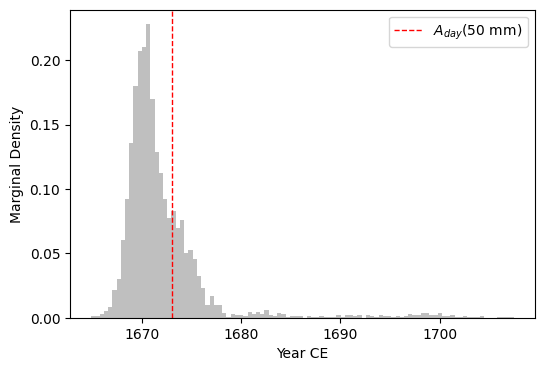

In [22]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

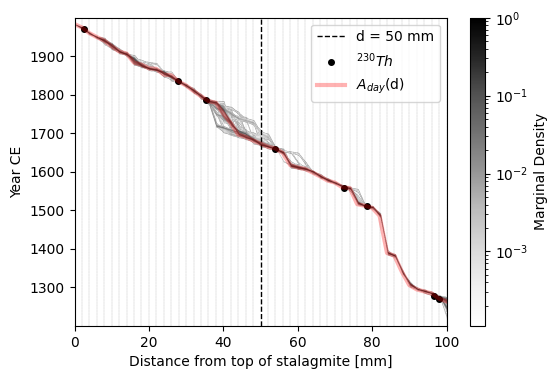

In [19]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(1200, 2000 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=3, alpha = 0.3, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

# del A, C
# gc.collect()


In [31]:
# from matplotlib import colors

# chain = 0
# X = samples[chain, cutout:, :].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==25: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'orange', linewidth=3, alpha = 0.2, label = r"$A_2(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/resampled_no_mean_{chain}_highT.jpg")
# plt.show()


In [32]:
# d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")